# Practical Session 03c — Choosing the model: cross-validation

**Companion to Lecture 03.** We cannot read the penalty $\lambda$ (or the degree) off the training
fit. This notebook picks it **honestly**:

* why a **single split** is noisy — different splits disagree on the "best" $\lambda$;
* **k-fold cross-validation from scratch**, checked against scikit-learn;
* choosing $\lambda$ at the **CV minimum**;
* the **honest workflow**: CV on train only (no leakage), then test **once**;
* **ridge vs lasso** on the real **diabetes** dataset.

> ⭐ **Key idea.** A validation split is itself random. **k-fold CV** averages the held-out error over
> $k$ rotating folds, giving a lower-variance estimate of generalization — the right quantity to
> minimize when tuning hyperparameters.

*Run each cell (Shift+Enter). Self-contained and offline (Section 5 uses a bundled dataset).*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from nb_utils import use_style
use_style("notes")
np.set_printoptions(precision=3, suppress=True)
BLUE, ORANGE, GREEN, GRAY = "#0072B2", "#D55E00", "#117733", "#7F7F7F"

rng = np.random.default_rng(1)
def truth(x):
    return np.sin(2 * np.pi * x)
x = np.sort(rng.uniform(0, 1, 40)); y = truth(x) + 0.18 * rng.standard_normal(40)

def poly(x, d):
    return np.vander(x, d + 1, increasing=True)
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def fit_poly_ridge(xt, yt, deg, lam):
    P = poly(xt, deg); s = np.abs(P).max(0); P = P / s      # column scaling from training
    w = np.linalg.solve(P.T @ P + lam * np.eye(deg + 1), P.T @ yt)
    return (w, s, deg)

def predict(model, xnew):
    w, s, deg = model
    return (poly(xnew, deg) / s) @ w

print("ready", x.shape)

ready (40,)


## 1. A single split is noisy

Take one random train/validation split and read off the "best" $\lambda$. Do it again with a
different split and you get a *different* answer — with little data, the winner is largely luck.

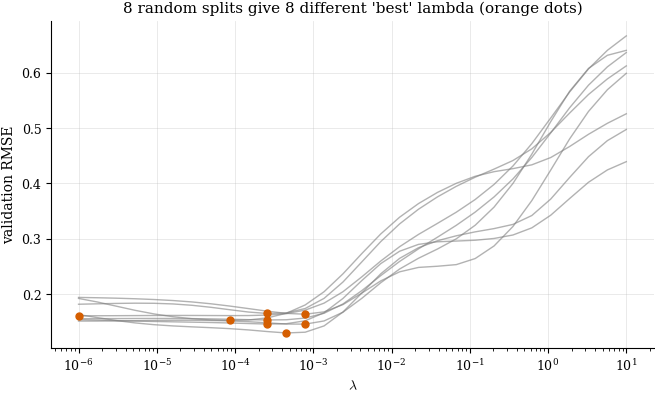

In [2]:
from sklearn.model_selection import train_test_split
lams = np.logspace(-6, 1, 30)
plt.figure(figsize=(6.6, 4))
for seed in range(8):
    xtr, xva, ytr, yva = train_test_split(x, y, test_size=0.3, random_state=seed)
    errs = [rmse(predict(fit_poly_ridge(xtr, ytr, 9, l), xva), yva) for l in lams]
    plt.plot(lams, errs, color=GRAY, alpha=0.6, lw=1)
    plt.scatter([lams[int(np.argmin(errs))]], [min(errs)], color=ORANGE, s=25, zorder=3)
plt.xscale("log"); plt.xlabel(r"$\lambda$"); plt.ylabel("validation RMSE")
plt.title("8 random splits give 8 different 'best' lambda (orange dots)"); plt.show()

## 2. k-fold cross-validation, from scratch

Partition the data into $k$ folds. Train on $k-1$, validate on the held-out one, rotate, and
**average** the $k$ scores. We implement the partition and the loop by hand, then confirm the loop
matches scikit-learn on *identical* folds.

In [3]:
def kfold_indices(n, k, seed=0):
    idx = np.random.default_rng(seed).permutation(n)
    return [idx[i::k] for i in range(k)]          # k roughly-equal, disjoint folds

def cross_val_rmse(xdata, ydata, deg, lam, k=5):
    n = len(xdata); scores = []
    for val in kfold_indices(n, k):
        tr = np.setdiff1d(np.arange(n), val)
        m = fit_poly_ridge(xdata[tr], ydata[tr], deg, lam)
        scores.append(rmse(predict(m, xdata[val]), ydata[val]))
    return np.mean(scores), np.std(scores)

# check the CV LOOP against scikit-learn: same folds, same ridge model -> same numbers
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
Xm, ym = make_regression(n_samples=100, n_features=6, noise=12.0, random_state=0)
Xm = (Xm - Xm.mean(0)) / Xm.std(0); ym = ym - ym.mean()
folds = kfold_indices(len(Xm), 5, seed=0)

def cv_our(lam):
    s = []
    for val in folds:
        tr = np.setdiff1d(np.arange(len(Xm)), val)
        w = np.linalg.solve(Xm[tr].T @ Xm[tr] + lam * np.eye(Xm.shape[1]), Xm[tr].T @ ym[tr])
        s.append(rmse(Xm[val] @ w, ym[val]))
    return np.mean(s)

def cv_sklearn(lam):
    s = []
    for val in folds:
        tr = np.setdiff1d(np.arange(len(Xm)), val)
        m = Ridge(alpha=lam, fit_intercept=False).fit(Xm[tr], ym[tr])
        s.append(rmse(m.predict(Xm[val]), ym[val]))
    return np.mean(s)

print(f"our CV loop = {cv_our(5.0):.4f}   sklearn model, same folds = {cv_sklearn(5.0):.4f}")
print("match:", np.isclose(cv_our(5.0), cv_sklearn(5.0)))

our CV loop = 15.9086   sklearn model, same folds = 15.9086
match: True


## 3. Pick $\lambda$ at the CV minimum

Sweep $\lambda$, compute the 5-fold CV RMSE at each (with its spread across folds), and take the
minimum. This is the honest stand-in for "generalization error" — no single lucky split.

CV-selected lambda = 1.49e-04


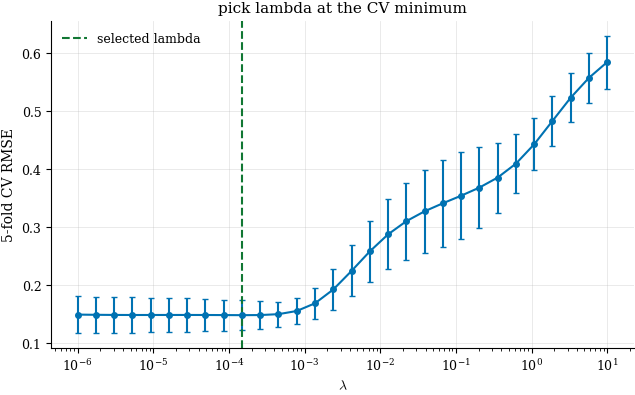

In [4]:
lams = np.logspace(-6, 1, 30)
stats = np.array([cross_val_rmse(x, y, 9, l) for l in lams])
means, stds = stats[:, 0], stats[:, 1]
best = lams[int(np.argmin(means))]
print(f"CV-selected lambda = {best:.2e}")

plt.figure(figsize=(6.4, 4))
plt.errorbar(lams, means, yerr=stds, marker="o", ms=4, color=BLUE, capsize=2)
plt.axvline(best, ls="--", color=GREEN, label="selected lambda")
plt.xscale("log"); plt.xlabel(r"$\lambda$"); plt.ylabel("5-fold CV RMSE")
plt.legend(); plt.title("pick lambda at the CV minimum"); plt.show()

## 4. The honest workflow (no leakage)

Hold out a **test** set up front. Choose $\lambda$ by cross-validation **on the training part only**,
with *all preprocessing inside the pipeline* (so the scaler is re-fit within each fold — no leakage).
Refit on all training data, then evaluate **once** on the test set. `GridSearchCV` automates the
CV + refit.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

xtr, xte, ytr, yte = train_test_split(x, y, test_size=0.3, random_state=0)
pipe = make_pipeline(PolynomialFeatures(9), StandardScaler(), Ridge())
grid = GridSearchCV(pipe, {"ridge__alpha": np.logspace(-6, 1, 30)}, cv=5,
                    scoring="neg_root_mean_squared_error")
grid.fit(xtr.reshape(-1, 1), ytr)
print("selected alpha (= lambda):", grid.best_params_["ridge__alpha"])
test = mean_squared_error(yte, grid.predict(xte.reshape(-1, 1))) ** 0.5
print(f"final TEST RMSE (test set touched once) = {test:.3f}")

selected alpha (= lambda): 0.0013738237958832637
final TEST RMSE (test set touched once) = 0.153


## 5. Real data: ridge & lasso on diabetes

The diabetes dataset (442 patients, 10 clinical features) is the classic shrinkage testbed. We
compare **OLS**, **ridge** (`RidgeCV` picks $\lambda$), and **lasso** (`LassoCV` picks $\lambda$) on
one train/test split, and read which features lasso keeps versus drops. With only 10 well-populated
features, shrinkage barely moves the RMSE here — its payoff is **interpretability** (lasso's exact
zeros). Regularization helps *more* when features are many, noisy, or collinear.

OLS    test RMSE = 56.4
Ridge  test RMSE = 56.5   (lambda = 10)
Lasso  test RMSE = 56.6   (lambda = 1.91)
Lasso KEEPS: ['sex', 'bmi', 'bp', 's1', 's2', 's3', 's5']
Lasso DROPS: ['age', 's4', 's6'] <- exactly 0


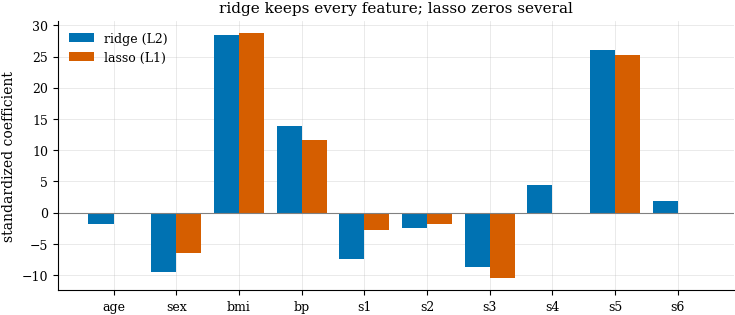

In [6]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = load_diabetes(); X, yy, names = data.data, data.target, data.feature_names
Xtr, Xte, ytr2, yte2 = train_test_split(X, yy, test_size=0.25, random_state=0)
alphas = np.logspace(-3, 1, 40)
test_rmse = lambda m: mean_squared_error(yte2, m.predict(Xte)) ** 0.5

ols   = LinearRegression().fit(Xtr, ytr2)
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas)).fit(Xtr, ytr2)
lasso = make_pipeline(StandardScaler(), LassoCV(alphas=alphas, max_iter=50000)).fit(Xtr, ytr2)
print(f"OLS    test RMSE = {test_rmse(ols):.1f}")
print(f"Ridge  test RMSE = {test_rmse(ridge):.1f}   (lambda = {ridge[-1].alpha_:.3g})")
print(f"Lasso  test RMSE = {test_rmse(lasso):.1f}   (lambda = {lasso[-1].alpha_:.3g})")

coef = lasso[-1].coef_
print("Lasso KEEPS:", [names[i] for i in range(len(names)) if abs(coef[i]) > 1e-8])
print("Lasso DROPS:", [names[i] for i in range(len(names)) if abs(coef[i]) <= 1e-8], "<- exactly 0")

xs = np.arange(len(names)); w = 0.4
plt.figure(figsize=(7.4, 3.2))
plt.bar(xs - w / 2, ridge[-1].coef_, w, label="ridge (L2)", color=BLUE)
plt.bar(xs + w / 2, lasso[-1].coef_, w, label="lasso (L1)", color=ORANGE)
plt.axhline(0, color="0.5", lw=0.8); plt.xticks(xs, names)
plt.ylabel("standardized coefficient"); plt.title("ridge keeps every feature; lasso zeros several")
plt.legend(); plt.show()

## Recap & exercises

**Recap.**
* One split is **noisy**; **k-fold CV** averages over folds for a stabler estimate of generalization.
* Our from-scratch CV loop matches scikit-learn on identical folds.
* Pick $\lambda$ at the **CV minimum**, then the **honest workflow** touches the test set exactly once.
* On diabetes (few features, ample data) regularization roughly **ties** OLS on RMSE; its payoff
  here is **lasso's sparsity** (features dropped to zero). Shrinkage wins bigger when features are
  many, noisy, or collinear.

**Exercises.**
1. Change `k` (3, 5, 10, and `n` = leave-one-out). How do the CV mean and spread change?
2. Apply the **1-standard-error rule**: pick the *simplest* $\lambda$ within one std of the best.
   Does it generalize as well?
3. In Section 4, swap `Ridge` for `Lasso` in the pipeline. Sparser model? Better test RMSE?
4. Wrap the whole workflow in an *outer* CV loop (**nested CV**) to estimate the tuned model's error
   without a single held-out test set.

*Next:* **Session 04 — Logistic regression**, which reuses this exact *regularize + cross-validate*
machinery for classification.